Se creó el archivo de ejemplo: clientes.csv

EVALUACIÓN DE LOS GRUPOS
 grupos   inercia  silhouette
      2 59.294631    0.273224
      3 41.710311    0.294414
      4 33.900282    0.286883
      5 26.453480    0.296148
      6 22.288270    0.292506

Número de grupos seleccionado: 5

PERFIL DE LOS GRUPOS
        edad  ingresos_mensuales  puntuacion_gasto  cantidad_clientes
grupo                                                                
0      36.22          3937777.00             34.44                  9
1      47.29          4363458.57             82.57                  7
2      58.50         10533744.00             82.75                  4
3      43.17          8103470.17             37.83                  6
4      22.75          3659945.25             73.75                  4

CLIENTES CLASIFICADOS
 cliente_id  edad  ingresos_mensuales  puntuacion_gasto  grupo
          1    56            11842490                54      2
          2    46             7313790                 4

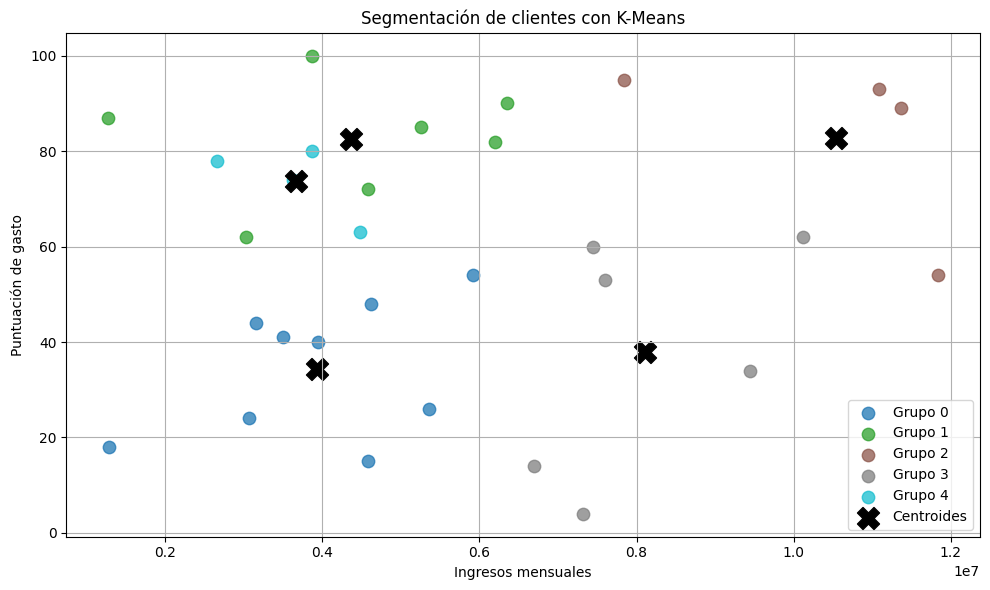


CLASIFICAR UN NUEVO CLIENTE
Edad: 30
Ingresos mensuales: 500000
Puntuación de gasto: 23

El nuevo cliente pertenece al grupo: 0

Características promedio del grupo:
edad                       36.22
ingresos_mensuales    3937777.00
puntuacion_gasto           34.44
cantidad_clientes           9.00


In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# ==========================================
# 1. Configuración
# ==========================================

ARCHIVO_DATOS = "clientes.csv"
ARCHIVO_MODELO = "modelo_clientes_kmeans.pkl"

COLUMNAS_ANALISIS = [
    "edad",
    "ingresos_mensuales",
    "puntuacion_gasto"
]

NUMERO_MINIMO_GRUPOS = 2
NUMERO_MAXIMO_GRUPOS = 6


# ==========================================
# 2. Crear datos de ejemplo
# ==========================================

if not os.path.exists(ARCHIVO_DATOS):
    np.random.seed(42)

    datos_ejemplo = pd.DataFrame({
        "cliente_id": range(1, 31),
        "edad": np.random.randint(18, 65, 30),
        "ingresos_mensuales": np.random.randint(
            1200000,
            12000000,
            30
        ),
        "puntuacion_gasto": np.random.randint(
            1,
            101,
            30
        )
    })

    datos_ejemplo.to_csv(
        ARCHIVO_DATOS,
        index=False,
        encoding="utf-8"
    )

    print(f"Se creó el archivo de ejemplo: {ARCHIVO_DATOS}")


# ==========================================
# 3. Cargar los datos
# ==========================================

try:
    datos = pd.read_csv(
        ARCHIVO_DATOS,
        encoding="utf-8"
    )
except FileNotFoundError:
    print(f"No se encontró el archivo '{ARCHIVO_DATOS}'.")
    exit()


if not all(columna in datos.columns for columna in COLUMNAS_ANALISIS):
    print("El archivo CSV debe contener estas columnas:")
    print(", ".join(COLUMNAS_ANALISIS))
    exit()


datos = datos.dropna(
    subset=COLUMNAS_ANALISIS
).copy()


for columna in COLUMNAS_ANALISIS:
    datos[columna] = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

datos = datos.dropna(
    subset=COLUMNAS_ANALISIS
).reset_index(drop=True)


if len(datos) < NUMERO_MINIMO_GRUPOS + 1:
    print("No hay suficientes clientes para aplicar K-Means.")
    exit()


# ==========================================
# 4. Preparar y estandarizar los datos
# ==========================================

X = datos[COLUMNAS_ANALISIS]

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)


# ==========================================
# 5. Probar diferentes números de grupos
# ==========================================

maximo_grupos = min(
    NUMERO_MAXIMO_GRUPOS,
    len(datos) - 1
)

resultados_k = []

for k in range(NUMERO_MINIMO_GRUPOS, maximo_grupos + 1):

    modelo_temporal = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )

    etiquetas = modelo_temporal.fit_predict(
        X_escalado
    )

    puntuacion_silhouette = silhouette_score(
        X_escalado,
        etiquetas
    )

    resultados_k.append({
        "grupos": k,
        "inercia": modelo_temporal.inertia_,
        "silhouette": puntuacion_silhouette
    })


resultados_k = pd.DataFrame(resultados_k)

mejor_k = int(
    resultados_k.loc[
        resultados_k["silhouette"].idxmax(),
        "grupos"
    ]
)

print("\nEVALUACIÓN DE LOS GRUPOS")
print("========================")
print(resultados_k.to_string(index=False))
print(f"\nNúmero de grupos seleccionado: {mejor_k}")


# ==========================================
# 6. Entrenar el modelo definitivo
# ==========================================

modelo = KMeans(
    n_clusters=mejor_k,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

datos["grupo"] = modelo.fit_predict(
    X_escalado
)


# ==========================================
# 7. Crear un perfil de cada grupo
# ==========================================

perfil_grupos = datos.groupby(
    "grupo"
)[COLUMNAS_ANALISIS].mean().round(2)

cantidad_clientes = datos.groupby(
    "grupo"
).size().rename(
    "cantidad_clientes"
)

perfil_grupos = perfil_grupos.join(
    cantidad_clientes
)

print("\nPERFIL DE LOS GRUPOS")
print("====================")
print(perfil_grupos)


# ==========================================
# 8. Mostrar los clientes clasificados
# ==========================================

print("\nCLIENTES CLASIFICADOS")
print("=====================")
print(datos.head(20).to_string(index=False))


# ==========================================
# 9. Guardar resultados
# ==========================================

datos.to_csv(
    "clientes_clasificados.csv",
    index=False,
    encoding="utf-8"
)

perfil_grupos.to_csv(
    "perfil_grupos_clientes.csv",
    encoding="utf-8"
)

modelo_guardado = {
    "modelo": modelo,
    "escalador": escalador,
    "columnas": COLUMNAS_ANALISIS
}

joblib.dump(
    modelo_guardado,
    ARCHIVO_MODELO
)

print("\nArchivos generados:")
print("- clientes_clasificados.csv")
print("- perfil_grupos_clientes.csv")
print(f"- {ARCHIVO_MODELO}")


# ==========================================
# 10. Visualizar los grupos
# ==========================================

plt.figure(figsize=(10, 6))

colores = plt.cm.tab10(
    np.linspace(0, 1, mejor_k)
)

for grupo in range(mejor_k):

    clientes_grupo = datos[
        datos["grupo"] == grupo
    ]

    plt.scatter(
        clientes_grupo["ingresos_mensuales"],
        clientes_grupo["puntuacion_gasto"],
        label=f"Grupo {grupo}",
        color=colores[grupo],
        s=80,
        alpha=0.75
    )

# Convertir los centroides desde la escala estándar
centroides_originales = escalador.inverse_transform(
    modelo.cluster_centers_
)

plt.scatter(
    centroides_originales[:, 1],
    centroides_originales[:, 2],
    marker="X",
    color="black",
    s=250,
    label="Centroides"
)

plt.xlabel("Ingresos mensuales")
plt.ylabel("Puntuación de gasto")
plt.title("Segmentación de clientes con K-Means")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# 11. Predecir el grupo de un nuevo cliente
# ==========================================

print("\nCLASIFICAR UN NUEVO CLIENTE")
print("===========================")

try:
    edad = float(input("Edad: "))
    ingresos = float(input("Ingresos mensuales: "))
    puntuacion = float(input("Puntuación de gasto: "))
except ValueError:
    print("Debes ingresar valores numéricos válidos.")
    exit()


nuevo_cliente = pd.DataFrame({
    "edad": [edad],
    "ingresos_mensuales": [ingresos],
    "puntuacion_gasto": [puntuacion]
})

nuevo_cliente_escalado = escalador.transform(
    nuevo_cliente[COLUMNAS_ANALISIS]
)

grupo_predicho = modelo.predict(
    nuevo_cliente_escalado
)[0]

print(
    f"\nEl nuevo cliente pertenece al grupo: "
    f"{grupo_predicho}"
)

print("\nCaracterísticas promedio del grupo:")

print(
    perfil_grupos.loc[
        grupo_predicho
    ].to_string()
)